# PA / PB1 peptide design — Summary analysis

Loads all ColabDesign generation/optimisation results and AF3 structural predictions,
compares metrics across predictors and protocols, and saves a shortlist of the best candidates.

In [ ]:
import json
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Paths

In [ ]:
import sys, os, pathlib

# Load .env from project root (one level up from notebooks/)
_env_path = pathlib.Path('..') / '.env'
if _env_path.exists():
    for _line in _env_path.read_text().splitlines():
        _line = _line.strip()
        if _line.startswith('export '):
            _line = _line[7:]
        if '=' in _line and not _line.startswith('#'):
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k.strip(), _v.strip())

sys.path.append('..')
import config

PRJ_DIR    = pathlib.Path('..').resolve()
SCRIPT_DIR = PRJ_DIR / 'notebooks'
COLAB_DIR  = pathlib.Path(config.RESULTS_DIR)
AF3_RESULTS_DIR  = pathlib.Path(config.AF3_RESULTS_DIR)
#AF3_SKIP = set(config.AF3_SKIP)

# Auto-discover all subdirectories under COLAB_DIR
COLAB_DIRS = {d.name: d for d in sorted(COLAB_DIR.iterdir()) if d.is_dir()}

for run, d in COLAB_DIRS.items():
    n = len(list(d.glob('*.json')))
    print(f'{run:30s}  ({n} JSON files)')

AttributeError: module 'config' has no attribute 'AF3_SKIP'

## 2. Load ColabDesign results

In [ ]:
def load_colab_results(colab_dir: pathlib.Path, source: str) -> pd.DataFrame:
    model = 'af2_multimer' if 'multimer' in source else 'af2'
    rows = []
    for jf in sorted(colab_dir.glob('*.json')):
        proto = jf.stem
        data  = json.loads(jf.read_text())
        for i, entry in enumerate(data.get('results', [])):
            rows.append({
                'source'     : source,
                'model'      : model,
                'group'      : f'{source}/{proto}',
                'name'       : f'{source}/{proto}_{i}',
                'protocol'   : proto,
                'idx'        : i,
                'seq'        : entry.get('seq', ''),
                'loss_total' : entry.get('loss_total'),
                'loss_af'    : entry.get('loss_af'),
                'energy'     : entry.get('energy'),
                'colab_iptm' : entry.get('i_ptm'),
                'colab_ptm'  : entry.get('ptm'),
                'colab_plddt': entry.get('plddt'),
            })
    if not rows:
        print(f'  [empty] {source}: no results found in {colab_dir}')
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    print(f'{source:30s}  model={model}  {len(df):4d} entries  ({df["protocol"].nunique()} protocols)')
    return df

frames = []
for run_name, run_dir in COLAB_DIRS.items():
    frames.append(load_colab_results(run_dir, run_name))

df_colab = pd.concat([f for f in frames if not f.empty], ignore_index=True)
print(f'\nTotal: {len(df_colab)} entries from {df_colab["group"].nunique()} (source, protocol) groups')
df_colab.head()

custom                          model=af2     6 entries  (1 protocols)
run1_protocols                  model=af2   180 entries  (12 protocols)
run2_wide                       model=af2   283 entries  (6 protocols)
run_multimer                    model=af2_multimer   147 entries  (3 protocols)

Total: 616 entries from 22 (source, protocol) groups


/tmp/ipykernel_249899/256980927.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_colab = pd.concat([f for f in frames if not f.empty], ignore_index=True)


,source,model,group,name,protocol,idx,seq,loss_total,loss_af,energy,colab_iptm,colab_ptm,colab_plddt
0,custom,af2,custom/seqs_aff_alberto_darren_6best,custom/seqs_aff_alberto_darren_6best_0,seqs_aff_alberto_darren_6best,0,MDFNPWLLFLKVPAQ,NaN,NaN,-1.017,0.189,0.888,0.308
1,custom,af2,custom/seqs_aff_alberto_darren_6best,custom/seqs_aff_alberto_darren_6best_1,seqs_aff_alberto_darren_6best,1,VDFNPWLLFLKVPAQ,NaN,NaN,-1.130,0.216,0.890,0.308
2,custom,af2,custom/seqs_aff_alberto_darren_6best,custom/seqs_aff_alberto_darren_6best_2,seqs_aff_alberto_darren_6best,2,IDFNPYLLFLKVPAQ,NaN,NaN,0.921,0.202,0.889,0.296
3,custom,af2,custom/seqs_aff_alberto_darren_6best,custom/seqs_aff_alberto_darren_6best_3,seqs_aff_alberto_darren_6best,3,MDWNPLLLHLKRPAQ,NaN,NaN,3.179,0.209,0.889,0.328
4,custom,af2,custom/seqs_aff_alberto_darren_6best,custom/seqs_aff_alberto_darren_6best_4,seqs_aff_alberto_darren_6best,4,VDYNPWLLFLRKPKQ,NaN,NaN,1.107,0.286,0.893,0.353


## 3. Load AF3 results

In [ ]:
def read_chain_b_seq(msa_dir: pathlib.Path) -> str:
    """Read peptide sequence (chain B) from unpaired MSA a3m file."""
    a3m_files = list(msa_dir.rglob('*_unpaired_msa_chains_b.a3m'))
    if not a3m_files:
        return ''
    lines = a3m_files[0].read_text().splitlines()
    for i, line in enumerate(lines):
        if line.startswith('>query') or (i == 0 and line.startswith('>')):
            if i + 1 < len(lines):
                return lines[i + 1].strip().upper()
    return ''


def load_af3_results(af3_dir: pathlib.Path, skip: set) -> pd.DataFrame:
    """
    For each sequence folder in af3_dir:
      - read peptide sequence from chain-B unpaired MSA
      - load all summary_confidences_*.json, pick best by ranking_score
      - extract AF3 confidence metrics
    Returns a DataFrame with one row per sequence.
    """
    rows = []
    for folder in sorted(af3_dir.iterdir()):
        if not folder.is_dir() or folder.name in skip:
            continue

        seq = read_chain_b_seq(folder / 'msas')
        if not seq:
            print(f'  [skip — no chain B MSA] {folder.name}')
            continue

        conf_files = sorted(folder.glob('*_summary_confidences_*.json'))
        if not conf_files:
            print(f'  [skip — no confidences] {folder.name}')
            continue

        best, best_score = None, -np.inf
        for cf in conf_files:
            c = json.loads(cf.read_text())
            score = c.get('ranking_score', -np.inf)
            if score > best_score:
                best_score = score
                best = c

        cpi = best.get('chain_pair_iptm', [[None, None], [None, None]])
        cpm = best.get('chain_pair_pae_min', [[None, None], [None, None]])
        cpt = best.get('chain_ptm', [None, None])
        cia = best.get('chain_iptm', [None, None])

        rows.append({
            'seq'                : seq,
            'af3_folder'         : folder.name,
            'af3_iptm'           : best.get('iptm'),
            'af3_ptm'            : best.get('ptm'),
            'af3_ranking_score'  : best.get('ranking_score'),
            'af3_has_clash'      : best.get('has_clash'),
            'af3_frac_disordered': best.get('fraction_disordered'),
            'af3_ptm_PA'         : cpt[0] if len(cpt) > 0 else None,
            'af3_ptm_pep'        : cpt[1] if len(cpt) > 1 else None,
            'af3_iptm_PA'        : cia[0] if len(cia) > 0 else None,
            'af3_iptm_pep'       : cia[1] if len(cia) > 1 else None,
            'af3_iptm_cross'     : cpi[1][0] if len(cpi) > 1 and len(cpi[1]) > 0 else None,
            'af3_pae_min_cross'  : cpm[1][0] if len(cpm) > 1 and len(cpm[1]) > 0 else None,
        })
        print(f'  {seq}  →  iptm={best.get("iptm"):.3f}  ptm={best.get("ptm"):.3f}  ranking={best.get("ranking_score"):.3f}')

    df = pd.DataFrame(rows)
    print(f'\nLoaded {len(df)} AF3 entries')
    return df

df_af3 = load_af3_results(AF3_RESULTS_DIR, AF3_SKIP)
df_af3.head()

NameError: name 'AF3_SKIP' is not defined

## 4. Merge ColabDesign + AF3

In [ ]:
def avg_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    num_cols = df.select_dtypes('number').columns.tolist()
    str_cols = [c for c in df.columns if c not in num_cols and c != 'name']
    agg = {c: 'mean' for c in num_cols}
    agg.update({c: 'first' for c in str_cols})
    return df.groupby('name', as_index=False).agg(agg)

df_colab_u = avg_duplicates(df_colab)

# Outer merge on seq: keeps all colab entries + af3-only entries (with NaN colab cols)
df = df_colab_u.merge(df_af3, on='seq', how='outer')

# AF3-only rows have no protocol from colab — label them 'other'
df['protocol'] = df['protocol'].fillna('other')

n_both       = (df['colab_iptm'].notna() & df['af3_iptm_cross'].notna()).sum()
n_colab_only = (df['colab_iptm'].notna() & df['af3_iptm_cross'].isna()).sum()
n_af3_only   = (df['colab_iptm'].isna()  & df['af3_iptm_cross'].notna()).sum()
print(f'{len(df)} total | {n_both} both | {n_colab_only} colab-only | {n_af3_only} AF3-only')
print(f'Protocols: {sorted(df["protocol"].unique())}')
df[['name', 'protocol', 'seq', 'colab_iptm', 'af3_iptm_cross']].head(10)


618 total | 54 both | 558 colab-only | 6 AF3-only
Protocols: ['gen_colabonly', 'gen_energy_A', 'gen_energy_B', 'gen_energy_C', 'opt_anneal_energy_A', 'opt_anneal_energy_B', 'opt_anneal_energy_C', 'opt_anneal_noenergy', 'opt_hard_energy_A', 'opt_hard_energy_B', 'opt_hard_energy_C', 'opt_hard_noenergy']


,name,protocol,model,seq,colab_iptm,af3_iptm_cross
0,run2_wide/gen_energy_A_27,gen_energy_A,af2,AAAGPGEALNLLLFC,0.360,NaN
1,run1_protocols/gen_energy_A_0,gen_energy_A,af2,AAFSPGELLLALLCC,0.421,NaN
2,run2_wide/gen_energy_A_0,gen_energy_A,af2,AAFSPGELLLALLCC,0.421,NaN
3,run1_protocols/gen_energy_A_14,gen_energy_A,af2,AAGGACALLNFLMEC,0.415,NaN
4,run2_wide/gen_energy_A_14,gen_energy_A,af2,AAGGACALLNFLMEC,0.415,NaN
5,run1_protocols/gen_energy_B_14,gen_energy_B,af2,AAGGADALLNFLMEC,0.417,NaN
6,run1_protocols/gen_energy_A_7,gen_energy_A,af2,AAGGADEALLLLMFL,0.267,NaN
7,run2_wide/gen_energy_A_7,gen_energy_A,af2,AAGGADEALLLLMFL,0.267,NaN
8,run1_protocols/gen_colabonly_7,gen_colabonly,af2,AAGGAGDLLLLLLCD,0.397,NaN
9,run1_protocols/gen_colabonly_13,gen_colabonly,af2,AAGGGAADLLLVMLN,0.441,NaN


## 5. Summary table

In [14]:
metric_cols = ['colab_iptm', 'colab_ptm', 'colab_plddt', 'energy', 'loss_af',
               'af3_iptm', 'af3_ptm', 'af3_iptm_cross', 'af3_ranking_score',
               'af3_has_clash', 'af3_frac_disordered']
display_cols = ['seq', 'protocol'] + [c for c in metric_cols if c in df.columns]
df_display = df.assign(protocol=df['protocol'].fillna('Other'))
df_display[display_cols].sort_values('af3_iptm_cross', ascending=False, na_position='last')

,seq,protocol,colab_iptm,colab_ptm,colab_plddt,energy,loss_af,af3_iptm,af3_ptm,af3_iptm_cross,af3_ranking_score,af3_has_clash,af3_frac_disordered
422,MDFNPWLLFLKVPAQ,Other,NaN,NaN,NaN,NaN,NaN,0.970,0.880,0.970,1.010,0.000,0.120
500,VDFNPWLLFLKVPAQ,Other,NaN,NaN,NaN,NaN,NaN,0.970,0.880,0.970,1.010,0.000,0.120
362,IDFNPYLLFLKVPAQ,Other,NaN,NaN,NaN,NaN,NaN,0.970,0.880,0.970,1.010,0.000,0.120
423,MDWNPLLLHLKRPAQ,Other,NaN,NaN,NaN,NaN,NaN,0.920,0.880,0.920,0.970,0.000,0.120
501,VDYNPWLLFLRKPKQ,Other,NaN,NaN,NaN,NaN,NaN,0.910,0.880,0.910,0.970,0.000,0.120
...,...,...,...,...,...,...,...,...,...,...,...,...,...
613,YVVGVFDHFARKEVL,opt_anneal_noenergy,0.233,0.880,0.335,4.912,4.453,NaN,NaN,NaN,NaN,NaN,NaN
614,YVVGVFDHFARKEVL,opt_anneal_noenergy,0.233,0.880,0.335,4.912,4.453,NaN,NaN,NaN,NaN,NaN,NaN
615,YWCEPPCHWKRAGLL,opt_hard_energy_C,0.134,0.886,0.376,-4.448,6.183,NaN,NaN,NaN,NaN,NaN,NaN
616,YWIQVFDWPAAKEWA,opt_anneal_noenergy,0.181,0.885,0.300,5.225,4.562,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Scatter plots — ColabDesign vs AF3

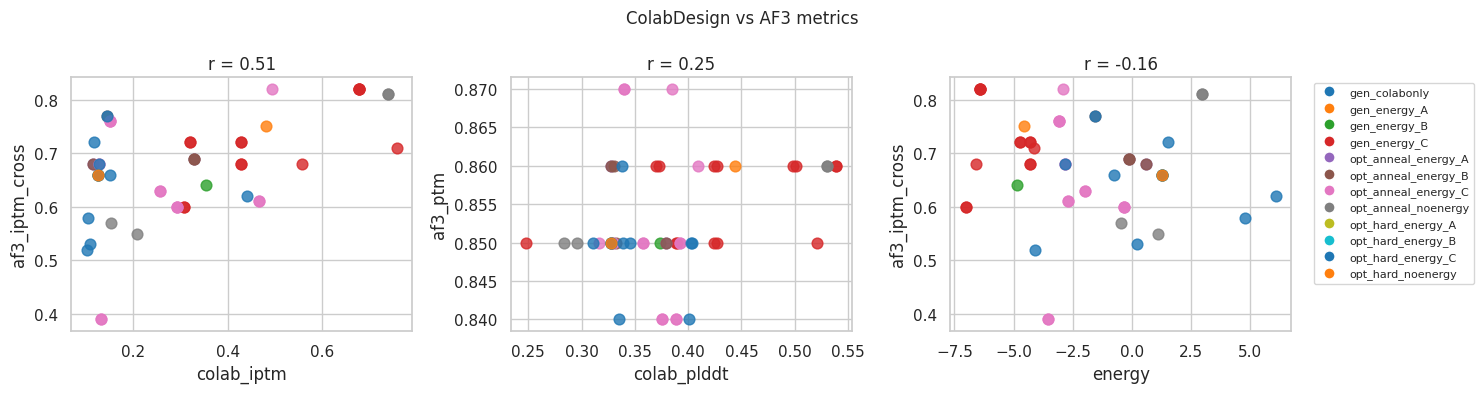

In [19]:
protocols = sorted(df['protocol'].dropna().unique())
palette   = dict(zip(protocols, sns.color_palette('tab10', len(protocols))))

pairs = [
    ('colab_iptm',  'af3_iptm_cross'),
    ('colab_plddt', 'af3_ptm'),
    ('energy',      'af3_iptm_cross'),
]
pairs = [(x, y) for x, y in pairs
         if x in df.columns and y in df.columns and df[y].notna().any()]

if pairs:
    fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))
    if len(pairs) == 1:
        axes = [axes]
    for ax, (xcol, ycol) in zip(axes, pairs):
        df_pair = df.dropna(subset=['protocol', xcol, ycol])
        for proto, grp in df_pair.groupby('protocol'):
            ax.scatter(grp[xcol], grp[ycol], label=proto,
                       color=palette.get(proto, 'grey'), s=60, alpha=0.8)
        r = df[[xcol, ycol]].dropna().corr().iloc[0, 1]
        ax.set_xlabel(xcol); ax.set_ylabel(ycol)
        ax.set_title(f'r = {r:.2f}')
    handles = [plt.Line2D([0],[0], marker='o', color='w',
                           markerfacecolor=palette[p], label=p, markersize=8)
               for p in protocols]
    axes[-1].legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    fig.suptitle('ColabDesign vs AF3 metrics', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('No AF3 results to correlate yet.')

## 7. Bar chart — iPTM per sequence

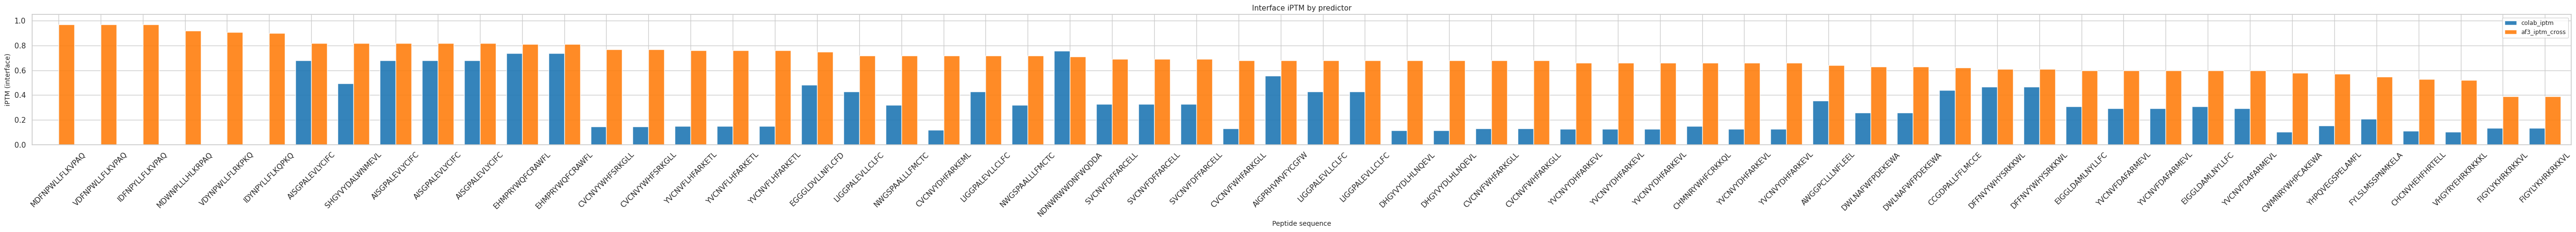

In [20]:
iptm_cols = [c for c in ['colab_iptm', 'af3_iptm_cross'] if c in df.columns]
sort_col  = 'af3_iptm_cross' if 'af3_iptm_cross' in iptm_cols else iptm_cols[0]

df_plot = (df[['seq'] + iptm_cols]
           .dropna(subset=[sort_col])
           .set_index('seq')
           .sort_values(sort_col, ascending=False))

ax = df_plot.plot(kind='bar', figsize=(max(10, len(df_plot) * 0.9), 5),
                  width=0.75, edgecolor='white', alpha=0.9)
ax.set_xlabel('Peptide sequence', fontsize=10)
ax.set_ylabel('iPTM (interface)', fontsize=10)
ax.set_title('Interface iPTM by predictor', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 8. Metric correlation heatmap

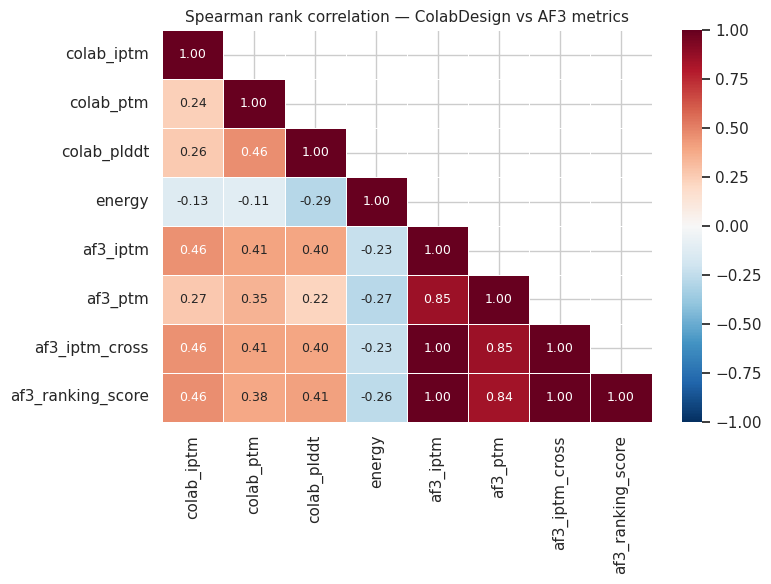

In [21]:
corr_cols = [c for c in [
    'colab_iptm', 'colab_ptm', 'colab_plddt', 'energy',
    'af3_iptm', 'af3_ptm', 'af3_iptm_cross', 'af3_ranking_score',
] if c in df.columns and df[c].notna().any()]

corr = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, mask=mask,
            linewidths=0.4, annot_kws={'size': 9})
ax.set_title('Spearman rank correlation — ColabDesign vs AF3 metrics', fontsize=11)
plt.tight_layout()
plt.show()

## 9. Protocol statistics

In [22]:
stat_cols = [c for c in ['af3_iptm_cross','colab_iptm'] if c in df.columns]
print('--- Mean ---')
display(df.groupby('protocol')[stat_cols].mean().round(3).sort_values(stat_cols, ascending=False))
print('--- Max ---')
display(df.groupby('protocol')[stat_cols].max().round(3).sort_values(stat_cols, ascending=False))

--- Mean ---


,af3_iptm_cross,colab_iptm
protocol,,
gen_energy_A,0.750,0.361
gen_energy_C,0.722,0.388
opt_anneal_energy_B,0.708,0.166
opt_anneal_noenergy,0.685,0.192
opt_anneal_energy_A,0.685,0.147
opt_hard_energy_A,0.660,0.110
opt_hard_energy_B,0.660,0.110
opt_hard_noenergy,0.660,0.110
opt_hard_energy_C,0.642,0.133


--- Max ---


,af3_iptm_cross,colab_iptm
protocol,,
gen_energy_C,0.820,0.759
opt_anneal_energy_C,0.820,0.495
opt_anneal_noenergy,0.810,0.739
opt_anneal_energy_B,0.770,0.425
opt_hard_energy_C,0.770,0.263
gen_energy_A,0.750,0.481
opt_anneal_energy_A,0.690,0.329
opt_hard_energy_A,0.660,0.126
opt_hard_energy_B,0.660,0.126


## 10. Rank comparison — ColabDesign vs AF3

In [23]:
key_metrics = [c for c in ['af3_iptm_cross', 'colab_iptm'] if c in df.columns]

df_rank = df[['seq', 'protocol'] + key_metrics].dropna(subset=key_metrics).copy()
for col in key_metrics:
    df_rank[f'rank_{col}'] = df_rank[col].rank(ascending=False).astype(int)

rank_cols = [f'rank_{c}' for c in key_metrics]
print(f'Ranking {len(df_rank)} sequences with both colab and AF3 predictions')
df_rank[['seq', 'protocol'] + key_metrics + rank_cols].sort_values(rank_cols[0])

Ranking 54 sequences with both colab and AF3 predictions


,seq,protocol,af3_iptm_cross,colab_iptm,rank_af3_iptm_cross,rank_colab_iptm
69,AISGPALEVLYCIFC,gen_energy_C,0.820,0.678,3,6
70,AISGPALEVLYCIFC,gen_energy_C,0.820,0.678,3,6
71,AISGPALEVLYCIFC,gen_energy_C,0.820,0.678,3,4
72,AISGPALEVLYCIFC,gen_energy_C,0.820,0.678,3,4
481,SHGYVYDALWNMEVL,opt_anneal_energy_C,0.820,0.495,3,9
246,EHMPRYWQFCRAWFL,opt_anneal_noenergy,0.810,0.739,6,2
245,EHMPRYWQFCRAWFL,opt_anneal_noenergy,0.810,0.739,6,2
142,CVCNVYWHFSRKGLL,opt_anneal_energy_B,0.770,0.144,8,38
143,CVCNVYWHFSRKGLL,opt_hard_energy_C,0.770,0.145,8,37
589,YVCNVFLHFARKETL,opt_anneal_energy_C,0.760,0.150,11,35


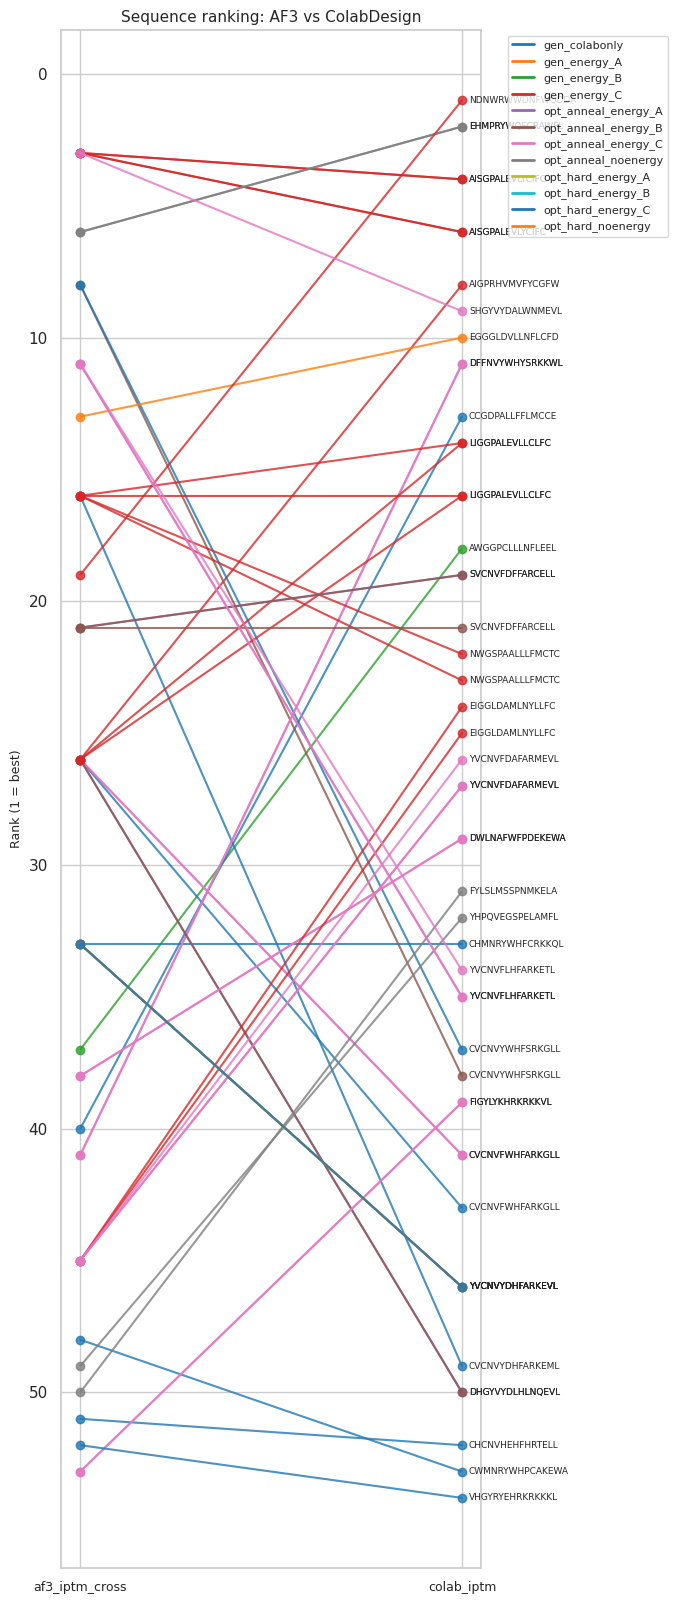

In [24]:
# Bump chart
if len(key_metrics) >= 2 and len(df_rank) > 0:
    fig, ax = plt.subplots(figsize=(max(7, len(key_metrics) * 2.5), max(5, len(df_rank) * 0.3)))
    x_pos = list(range(len(key_metrics)))

    for _, row in df_rank.iterrows():
        ranks = [row[f'rank_{c}'] for c in key_metrics]
        color = palette.get(row['protocol'], 'grey')
        ax.plot(x_pos, ranks, marker='o', color=color, alpha=0.8, lw=1.5)
        ax.annotate(row['seq'], (x_pos[-1], ranks[-1]),
                    fontsize=6.5, va='center', xytext=(5, 0), textcoords='offset points')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(key_metrics, fontsize=9)
    ax.invert_yaxis()
    ax.set_ylabel('Rank (1 = best)', fontsize=9)
    ax.set_title('Sequence ranking: AF3 vs ColabDesign', fontsize=11)
    handles = [plt.Line2D([0],[0], color=c, lw=2, label=p) for p, c in palette.items()]
    ax.legend(handles=handles, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough data for bump chart.')

## 11. Save best candidates

Selection strategy (≤ 50 total):
1. All entries that have an AF3 prediction (`af3_iptm_cross` not NaN)
2. Fill remaining budget with top ColabDesign entries by `colab_iptm` (not already in AF3 set)

In [25]:
MAX_CANDIDATES = 50

has_af3   = df['af3_iptm_cross'].notna()
df_with_af3 = df[has_af3].sort_values('af3_iptm_cross', ascending=False)

budget    = max(0, MAX_CANDIDATES - len(df_with_af3))
df_top_colab = (
    df[~has_af3 & df['colab_iptm'].notna()]
    .sort_values('colab_iptm', ascending=False)
    .head(budget)
)

df_best = pd.concat([df_with_af3, df_top_colab], ignore_index=True)
print(f'{len(df_best)} candidates total:')
print(f'  {len(df_with_af3)} with AF3 prediction')
print(f'  {len(df_top_colab)} top colab_iptm (no AF3)')

save_cols = ['seq', 'protocol', 'model', 'name',
             'colab_iptm', 'colab_ptm', 'colab_plddt', 'energy',
             'af3_iptm_cross', 'af3_iptm', 'af3_ptm', 'af3_ranking_score',
             'af3_has_clash', 'af3_frac_disordered', 'af3_folder']
save_cols = [c for c in save_cols if c in df_best.columns]

OUT = PRJ_DIR / 'results' / 'summary_best_candidates.csv'
OUT.parent.mkdir(parents=True, exist_ok=True)
df_best[save_cols].to_csv(OUT, index=False)
print(f'Saved to {OUT}')

df_best[save_cols]

60 candidates total:
  60 with AF3 prediction
  0 top colab_iptm (no AF3)
Saved to /nobackup/gu281776/Projects/protein_design/prg/PA_PB1/results/summary_best_candidates.csv


,seq,protocol,model,name,colab_iptm,colab_ptm,colab_plddt,energy,af3_iptm_cross,af3_iptm,af3_ptm,af3_ranking_score,af3_has_clash,af3_frac_disordered,af3_folder
0,MDFNPWLLFLKVPAQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.970,0.970,0.880,1.010,0.000,0.120,fold_2026_04_16_mdfnpwllflkvpaq
1,VDFNPWLLFLKVPAQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.970,0.970,0.880,1.010,0.000,0.120,fold_2026_04_16_vdfnpwllflkvpaq
2,IDFNPYLLFLKVPAQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.970,0.970,0.880,1.010,0.000,0.120,fold_2026_04_16_idfnpyllflkvpaq
3,MDWNPLLLHLKRPAQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.920,0.920,0.880,0.970,0.000,0.120,fold_2026_04_16_mdwnplllhlkrpaq
4,VDYNPWLLFLRKPKQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.910,0.910,0.880,0.970,0.000,0.120,fold_2026_04_16_vdynpwllflrkpkq
5,IDYNPYLLFLKQPKQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.900,0.900,0.880,0.950,0.000,0.110,fold_2026_04_16_idynpyllflkqpkq
6,AISGPALEVLYCIFC,gen_energy_C,af2,run1_protocols/gen_energy_C_16,0.678,0.909,0.539,-6.437,0.820,0.820,0.860,0.880,0.000,0.110,fold_2026_04_16_aisgpalevlycifc
7,SHGYVYDALWNMEVL,opt_anneal_energy_C,af2,run1_protocols/opt_anneal_energy_C_2,0.495,0.902,0.410,-2.916,0.820,0.820,0.860,0.880,0.000,0.110,fold_2026_04_08_SHGYVYDALWNMEVL
8,AISGPALEVLYCIFC,gen_energy_C,af2,run2_wide/gen_energy_C_16,0.678,0.901,0.501,-6.437,0.820,0.820,0.860,0.880,0.000,0.110,fold_2026_04_16_aisgpalevlycifc
9,AISGPALEVLYCIFC,gen_energy_C,af2,run1_protocols/gen_energy_C_9,0.678,0.909,0.539,-6.437,0.820,0.820,0.860,0.880,0.000,0.110,fold_2026_04_16_aisgpalevlycifc
